In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


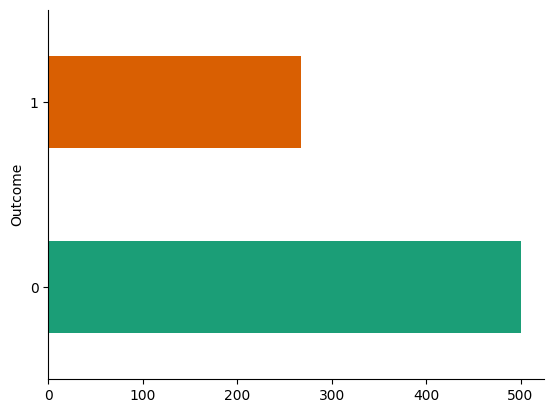

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Outcome').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2')) # Use the 'df' DataFrame instead of '_df_4'
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

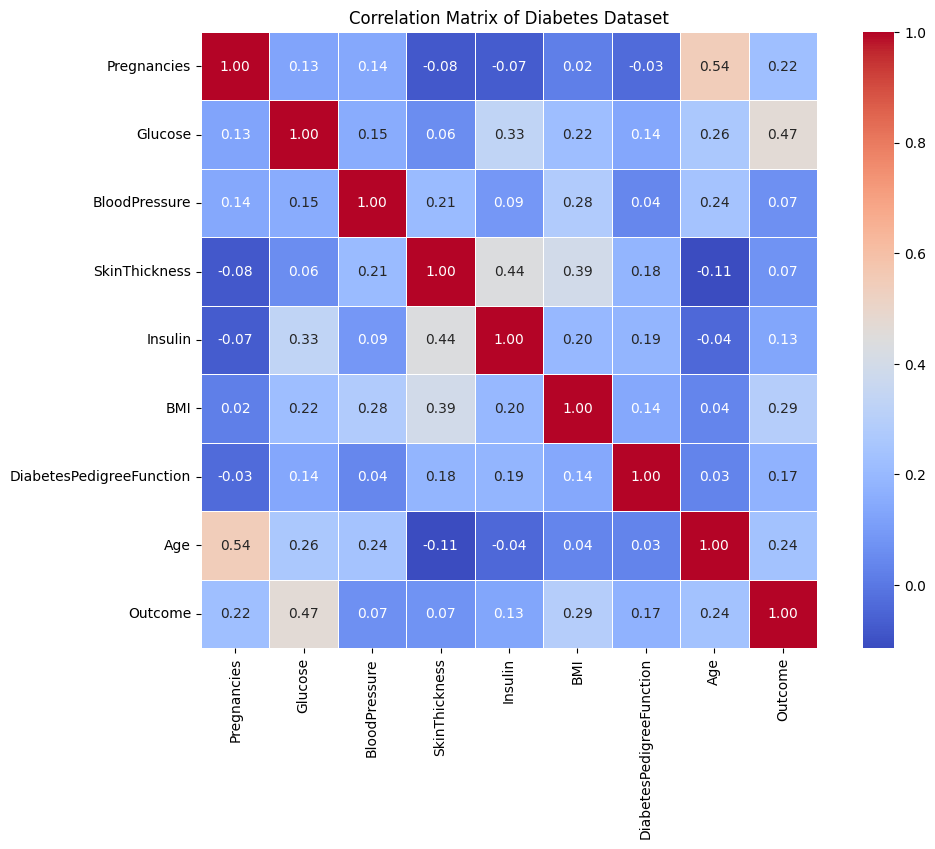

In [ ]:
#df.corr()
df_numeric = df.select_dtypes(exclude=['object'])
correlations = df_numeric.corr()
print(correlations)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the diabetes dataset (replace 'diabetes.csv' with your dataset path)
# Assuming the dataset is in CSV format and has no missing values
data = pd.read_csv('diabetes.csv')

# Display the first few rows of the dataset
print(data.head())

# Compute the correlation matrix
correlation_matrix = data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Generate a heatmap to visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

# Set the title of the heatmap
plt.title('Correlation Matrix of Diabetes Dataset')

# Show the plot
plt.show()


In [ ]:
from sklearn.svm import SVC

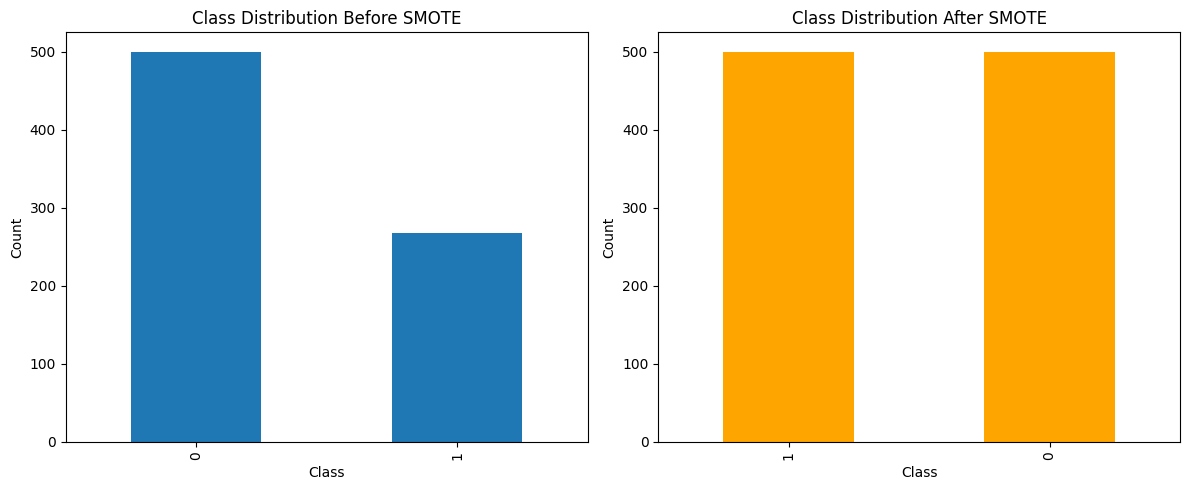


=== Classification Report: Random Forest after SMOTE and RFE ===
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.80      0.81       100
    Diabetic       0.80      0.82      0.81       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



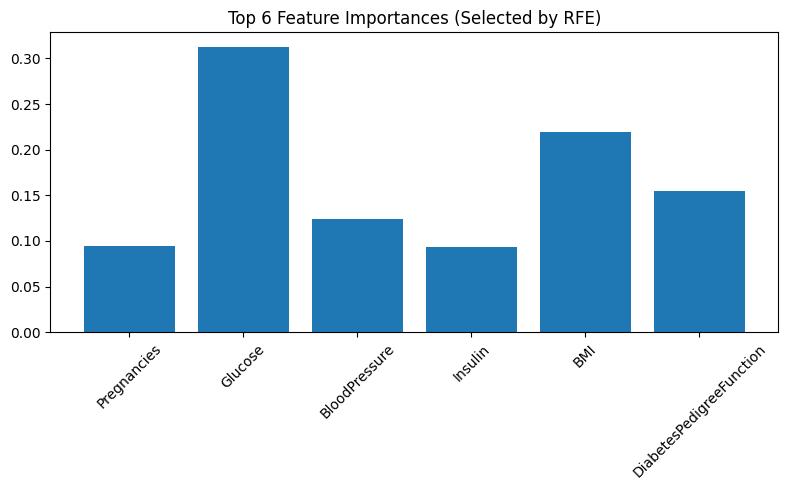

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Load the dataset
file_path = 'diabetes.csv'  # Use full path if necessary
data = pd.read_csv(file_path)

# Drop unnecessary columns (if required)
# NOTE: Only drop if your dataset has extra columns, otherwise skip
# data.drop(data.columns[[-3, -4]], axis=1, inplace=True)  # Remove if not applicable

# Replace '?' with NaN (for dirty datasets)
data.replace('?', np.nan, inplace=True)

# Identify numeric columns and convert them
numeric_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill missing values with median
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].median())

# Encode categorical features (if any)
label_encoders = {}
for col in data.select_dtypes(include='object').columns:
    if col != 'Outcome':
        label_encoders[col] = LabelEncoder()
        data[col] = label_encoders[col].fit_transform(data[col])

# Encode target if needed (should already be binary 0/1)
if data['Outcome'].dtype == 'object':
    le_target = LabelEncoder()
    data['Outcome'] = le_target.fit_transform(data['Outcome'])

# Plot class distribution before SMOTE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
data['Outcome'].value_counts().plot(kind='bar', title='Class Distribution Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

# Apply SMOTE
X = data.drop('Outcome', axis=1)
y = data['Outcome']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Plot class distribution after SMOTE
plt.subplot(1, 2, 2)
pd.Series(y_resampled).value_counts().plot(kind='bar', color='orange', title='Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.2, random_state=42, stratify=y_resampled)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature selection using RFE with Logistic Regression
log_reg = LogisticRegression(max_iter=10000, solver='saga')  # saga supports l1+l2
rfe = RFE(log_reg, n_features_to_select=6)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

# Train Random Forest
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_rfe, y_train)

# Predict and evaluate
y_pred = rf_classifier.predict(X_test_rfe)
print("\n=== Classification Report: Random Forest after SMOTE and RFE ===")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Feature importances plot
importances = rf_classifier.feature_importances_
plt.figure(figsize=(8, 5))
plt.title("Top 6 Feature Importances (Selected by RFE)")
plt.bar(range(len(importances)), importances, align="center")
plt.xticks(range(len(importances)), np.array(X.columns)[rfe.support_], rotation=45)
plt.tight_layout()
plt.show()

# Save processed data
def save_data(X, y, filename_prefix):
    X_df = pd.DataFrame(X, columns=[f"F{i}" for i in range(X.shape[1])])
    y_df = pd.Series(y, name='Outcome')
    pd.concat([X_df, y_df], axis=1).to_csv(f"{filename_prefix}.csv", index=False)

save_data(X_train_rfe, y_train, 'X_train_SMOTE')
save_data(X_test_rfe, y_test, 'X_test_SMOTE')

# Load when needed
def load_data(filename):
    df = pd.read_csv(filename)
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']
    return X, y

X_train_loaded, y_train_loaded = load_data('X_train_SMOTE.csv')
X_test_loaded, y_test_loaded = load_data('X_test_SMOTE.csv')


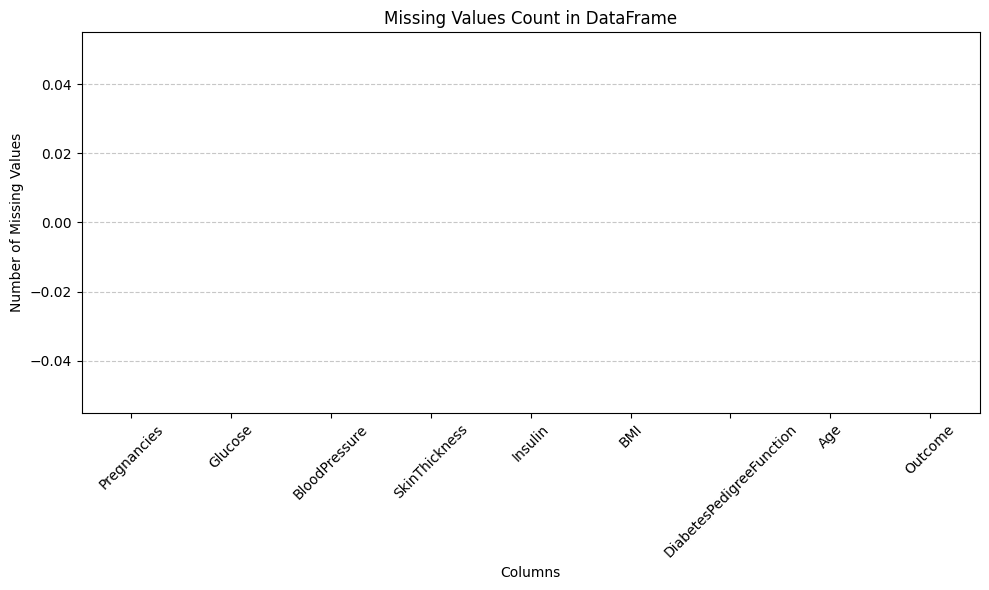

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is your DataFrame
missing_counts = df.isnull().sum()

# Plotting
plt.figure(figsize=(10, 6))
missing_counts.plot(kind='bar', color='skyblue')
plt.title('Missing Values Count in DataFrame')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


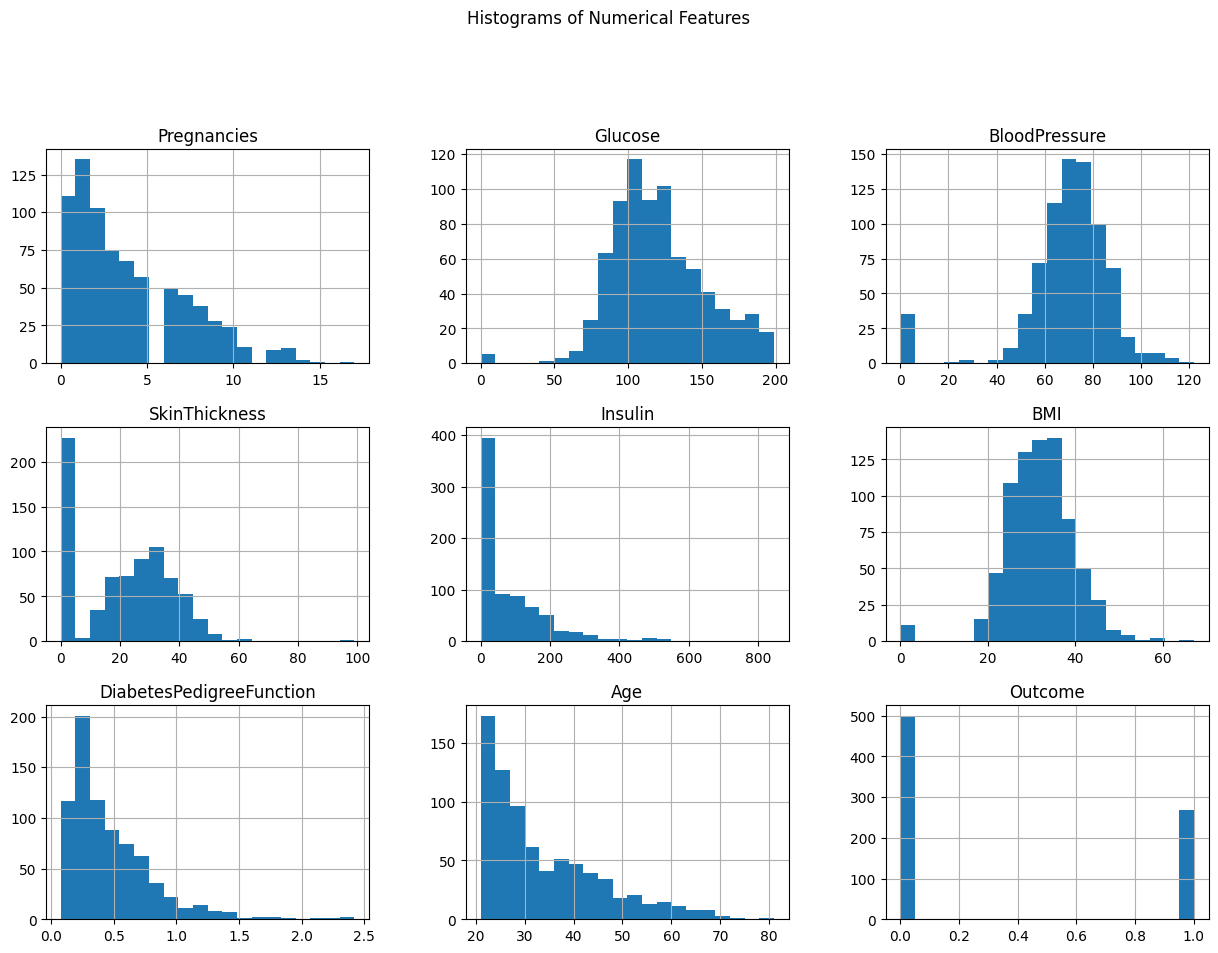

<Figure size 9000x6000 with 0 Axes>

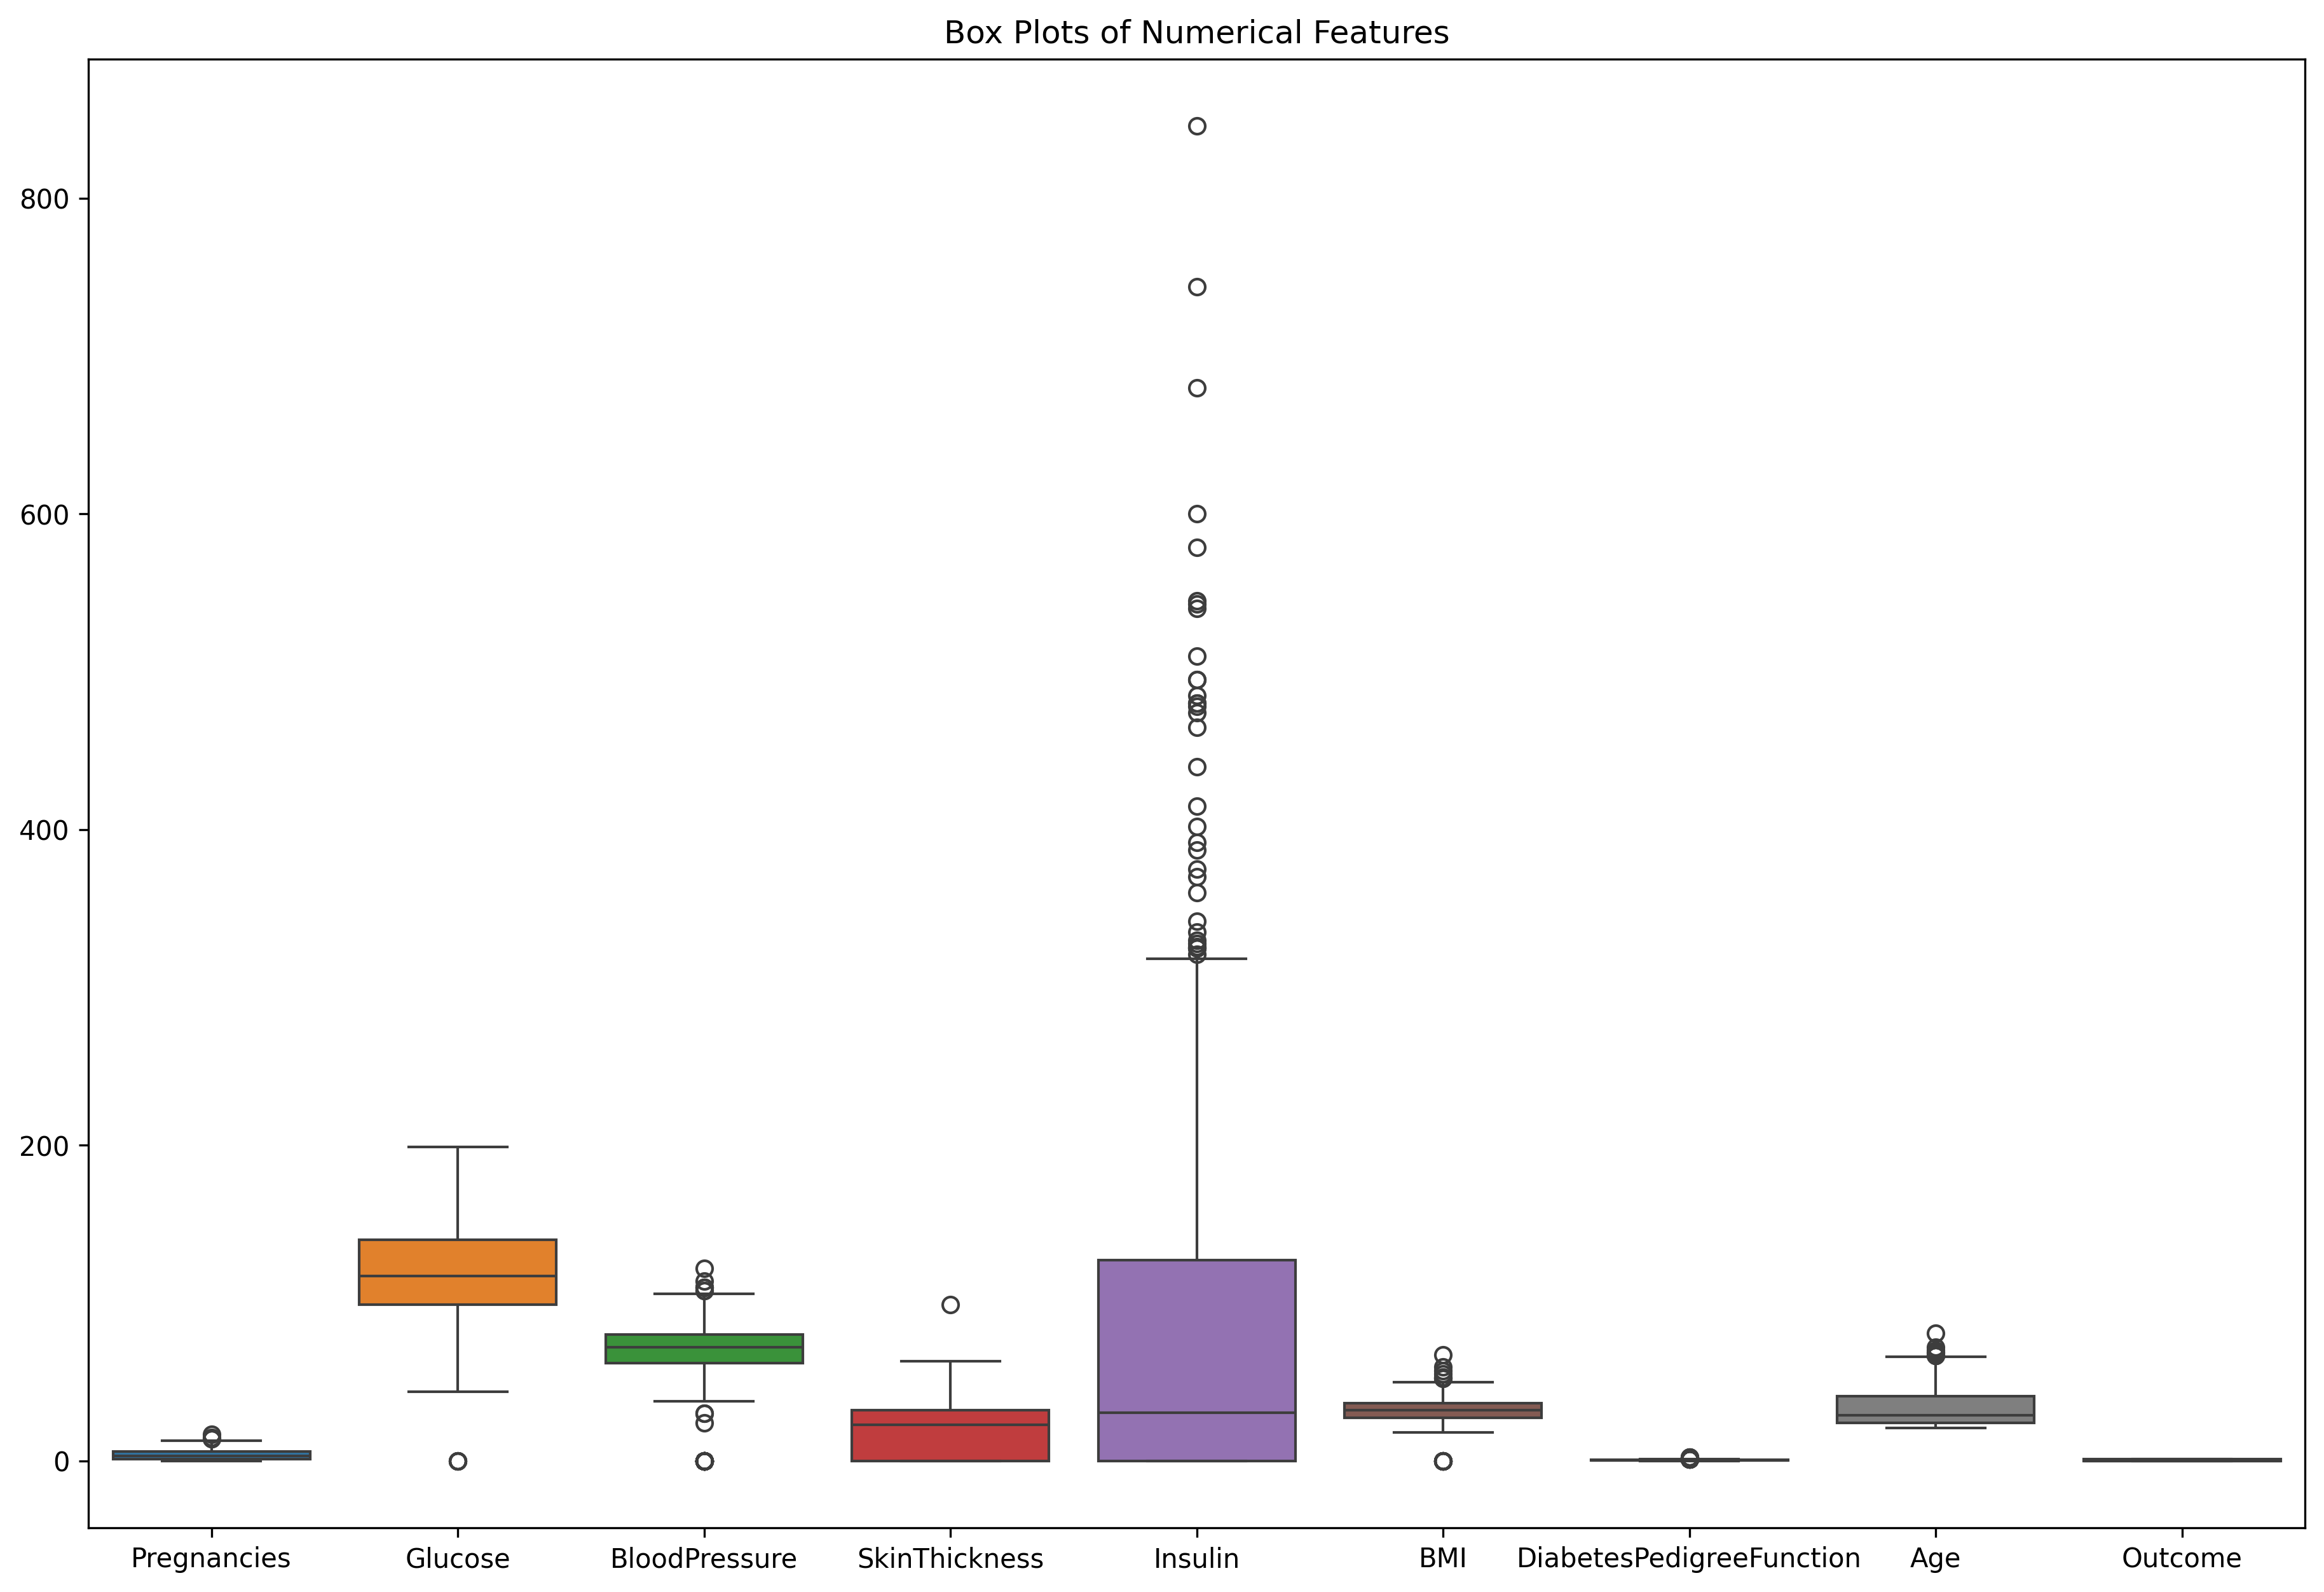

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Visualize the distribution of each feature
# Histograms for numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_features].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.figure(figsize=(15, 10), dpi  = 600)
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 10), dpi  = 300)
sns.boxplot(data=df[numerical_features])
plt.title('Box Plots of Numerical Features')
plt.show()

# Count plots for categorical features
categorical_features = df.select_dtypes(include=['object']).columns
for feature in categorical_features:
    plt.figure(figsize=(10, 6), dpi  = 300)
    sns.countplot(x=feature, data=df, palette='viridis')
    plt.title(f'Count Plot of {feature}')
    plt.show()


# Models Training and Development

Random Forest With Hyperparameter Tuning

In [ ]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load dataset
data = pd.read_csv("diabetes.csv")

# Separate features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test split (before SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE on the training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Train Random Forest model
model_rfs = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    max_depth=6,
    max_leaf_nodes=6,
    random_state=42
)

model_rfs.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = model_rfs.predict(X_test_scaled)

# Evaluation
print("=== Classification Report (With SMOTE) ===")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Save the best model
with open('best_rf_model_with_smote_tuning.pkl', 'wb') as f:
    pickle.dump(model_rfs, f)


=== Classification Report (With SMOTE) ===
              precision    recall  f1-score   support

Non-Diabetic       0.86      0.71      0.78       100
    Diabetic       0.59      0.78      0.67        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.76      0.73      0.74       154



In [ ]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv("diabetes.csv")

# Separate features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Split the data (25% test, 75% train)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (optional, but useful)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the Random Forest model
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    max_depth=6,
    max_leaf_nodes=6,
    random_state=42
)

# Train the model
model_rf.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model_rf.predict(X_test_scaled)

# Evaluation
print("=== Classification Report (Without SMOTE) ===")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Save the best model
with open('best_rf_model_without_smote_tuning.pkl', 'wb') as f:
    pickle.dump(model_rf, f)


=== Classification Report (Without SMOTE) ===
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.88      0.81       100
    Diabetic       0.68      0.46      0.55        54

    accuracy                           0.73       154
   macro avg       0.71      0.67      0.68       154
weighted avg       0.73      0.73      0.72       154



In [ ]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Load dataset
data = pd.read_csv("diabetes.csv")

# Separate features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test split (25% test, 75% train)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Logistic Regression model
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = model_lr.predict(X_test_scaled)

# Evaluate the model
print("=== Classification Report: Logistic Regression (Without SMOTE) ===")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Save the best model
with open('best_lr_model_without_smote_tuning.pkl', 'wb') as f:
    pickle.dump(model_lr, f)


=== Classification Report: Logistic Regression (Without SMOTE) ===
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.82      0.79       100
    Diabetic       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [ ]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Load dataset
data = pd.read_csv("diabetes.csv")

# Separate features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test split (before applying SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Initialize and train Logistic Regression model
model_lrs = LogisticRegression(max_iter=1000, random_state=42)
model_lrs.fit(X_train_resampled, y_train_resampled)

# Predict on test data (not SMOTEd)
y_pred = model_lrs.predict(X_test_scaled)

# Evaluation
print("=== Classification Report: Logistic Regression (With SMOTE) ===")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Save the best model
with open('best_lr_model_with_smote_tuning.pkl', 'wb') as f:
    pickle.dump(model_lrs, f)


=== Classification Report: Logistic Regression (With SMOTE) ===
              precision    recall  f1-score   support

Non-Diabetic       0.83      0.76      0.79       100
    Diabetic       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



In [ ]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Load dataset
data = pd.read_csv("diabetes.csv")

# Split into features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test_scaled)

print("=== Classification Report: KNN (Without SMOTE) ===")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Save the best model
with open('best_knn_model_without_smote_tuning.pkl', 'wb') as f:
    pickle.dump(knn, f)


=== Classification Report: KNN (Without SMOTE) ===
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.80      0.78       100
    Diabetic       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [ ]:
import pickle
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Train KNN on balanced data
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate on original test set
y_pred_smote = knn_smote.predict(X_test_scaled)

print("=== Classification Report: KNN (With SMOTE) ===")
print(classification_report(y_test, y_pred_smote, target_names=["Non-Diabetic", "Diabetic"]))

# Save the best model
with open('best_knn_model_with_smote_tuning.pkl', 'wb') as f:
    pickle.dump(knn_smote, f)


=== Classification Report: KNN (With SMOTE) ===
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.64      0.71       100
    Diabetic       0.51      0.69      0.58        54

    accuracy                           0.66       154
   macro avg       0.65      0.66      0.64       154
weighted avg       0.69      0.66      0.66       154



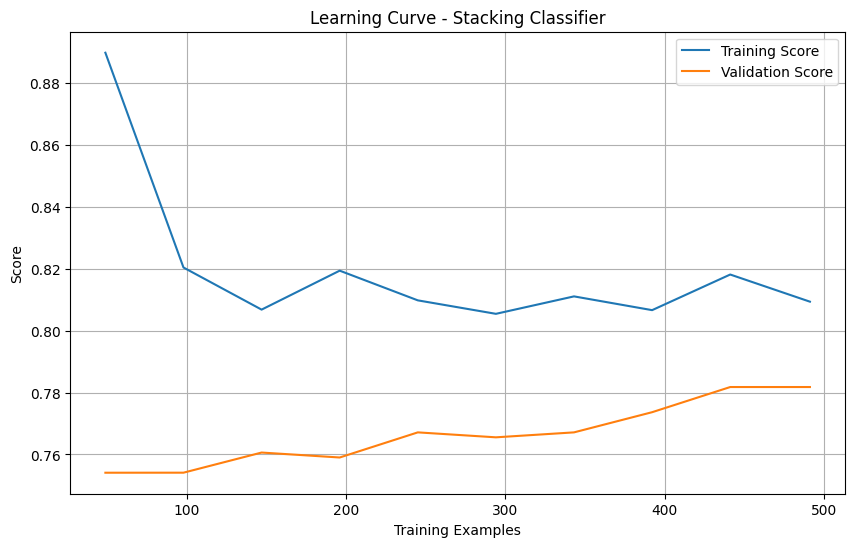

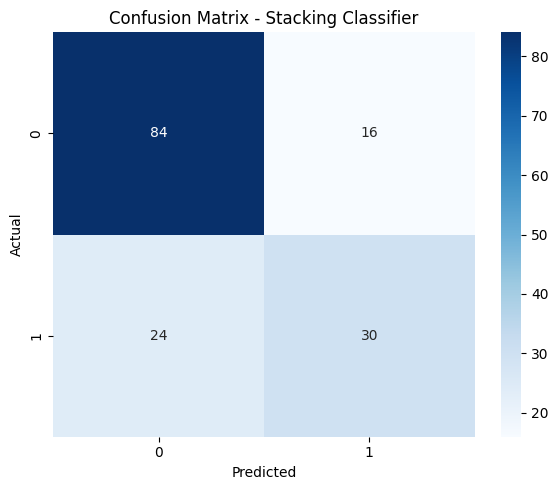


=== Classification Report: Stacking Classifier ===
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.84      0.81       100
    Diabetic       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



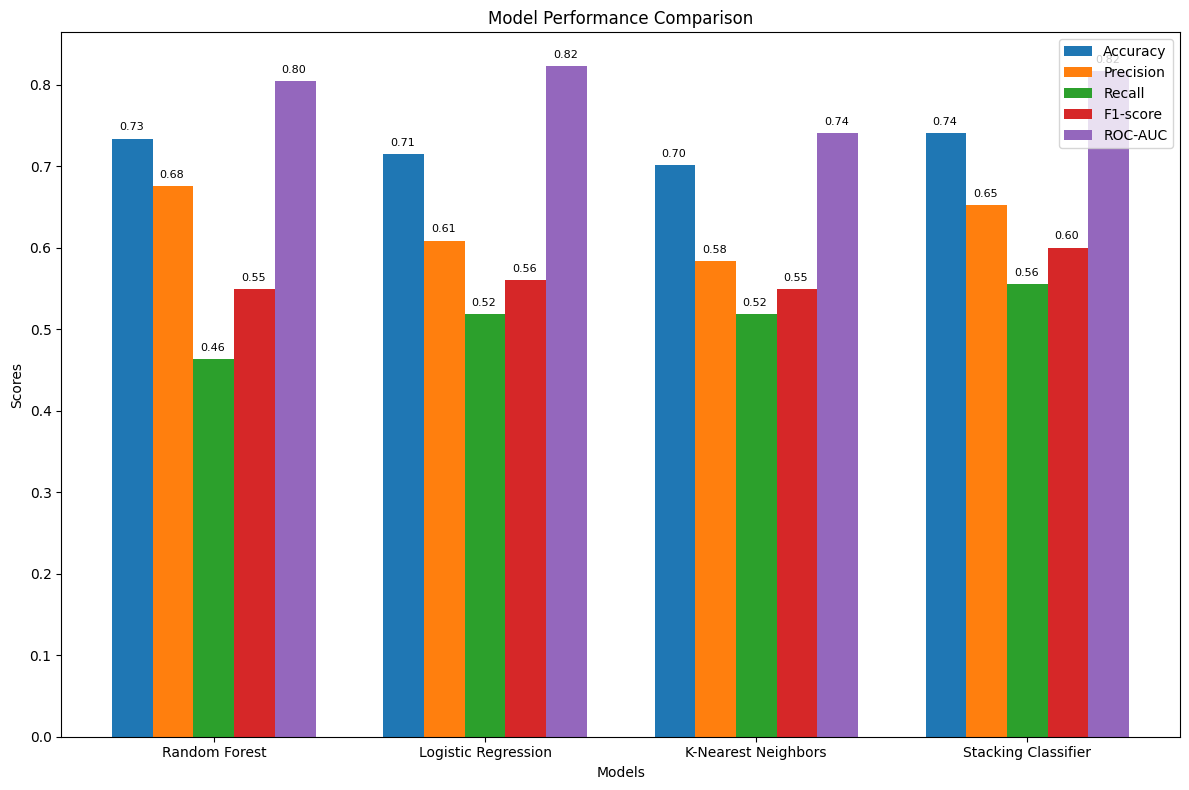

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.preprocessing import StandardScaler

# Load your real dataset
data = pd.read_csv("diabetes.csv")
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load best individual models (ensure they were trained on scaled data!)
with open('best_rf_model_without_smote_tuning.pkl', 'rb') as f:
    model_rf = pickle.load(f)

with open('best_lr_model_without_smote_tuning.pkl', 'rb') as f:
    model_lr = pickle.load(f)

with open('best_knn_model_without_smote_tuning.pkl', 'rb') as f:
    knn = pickle.load(f)

# Define base learners
estimators = [
    ('rf', model_rf),
    ('lr', model_lr),
    ('knn', knn)
]

# Define the stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    passthrough=False,
    n_jobs=-1
)

# Train stacking model
stacking_clf.fit(X_train_scaled, y_train)

# Predict
y_pred = stacking_clf.predict(X_test_scaled)
y_prob = stacking_clf.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Metrics table
models = {
    'Random Forest': model_rf,
    'Logistic Regression': model_lr,
    'K-Nearest Neighbors': knn,
    'Stacking Classifier': stacking_clf
}

metrics = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-score': [], 'ROC-AUC': []}

for name, model in models.items():
    y_p = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics['Model'].append(name)
    metrics['Accuracy'].append(accuracy_score(y_test, y_p))
    metrics['Precision'].append(precision_score(y_test, y_p))
    metrics['Recall'].append(recall_score(y_test, y_p))
    metrics['F1-score'].append(f1_score(y_test, y_p))
    metrics['ROC-AUC'].append(roc_auc_score(y_test, y_proba))

metrics_df = pd.DataFrame(metrics)

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    stacking_clf, X_train_scaled, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Score')
plt.title('Learning Curve - Stacking Classifier')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification Report
print("\n=== Classification Report: Stacking Classifier ===")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Comparative Bar Plot
plt.figure(figsize=(12, 8))
bar_width = 0.15
index = np.arange(len(metrics_df['Model']))

for i, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']):
    plt.bar(index + i * bar_width, metrics_df[metric], bar_width, label=metric)

# Add text labels
for i in range(len(metrics_df['Model'])):
    for j, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']):
        plt.text(index[i] + j * bar_width - 0.05, metrics_df[metric][i] + 0.01,
                 f"{metrics_df[metric][i]:.2f}", fontsize=8)

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(index + 0.3, metrics_df['Model'])
plt.legend()
plt.tight_layout()
plt.show()

# Save the Stacking Model
with open("stacking_model.pkl", "wb") as f:
    pickle.dump(stacking_clf, f)


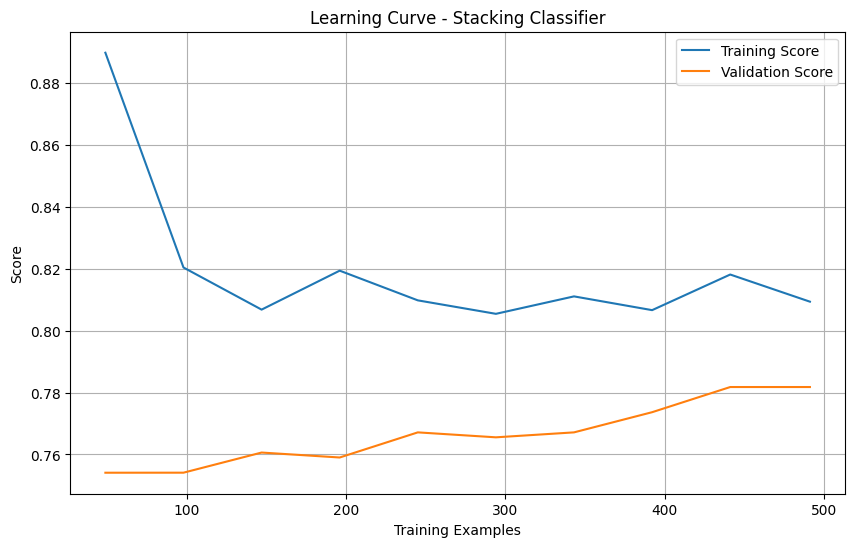

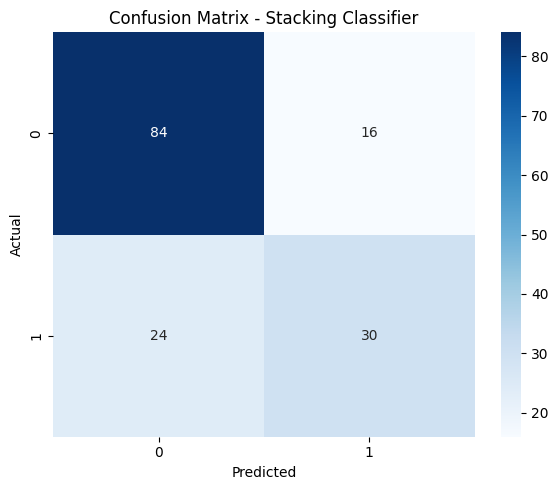


=== Classification Report: Stacking Classifier ===
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.84      0.81       100
    Diabetic       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



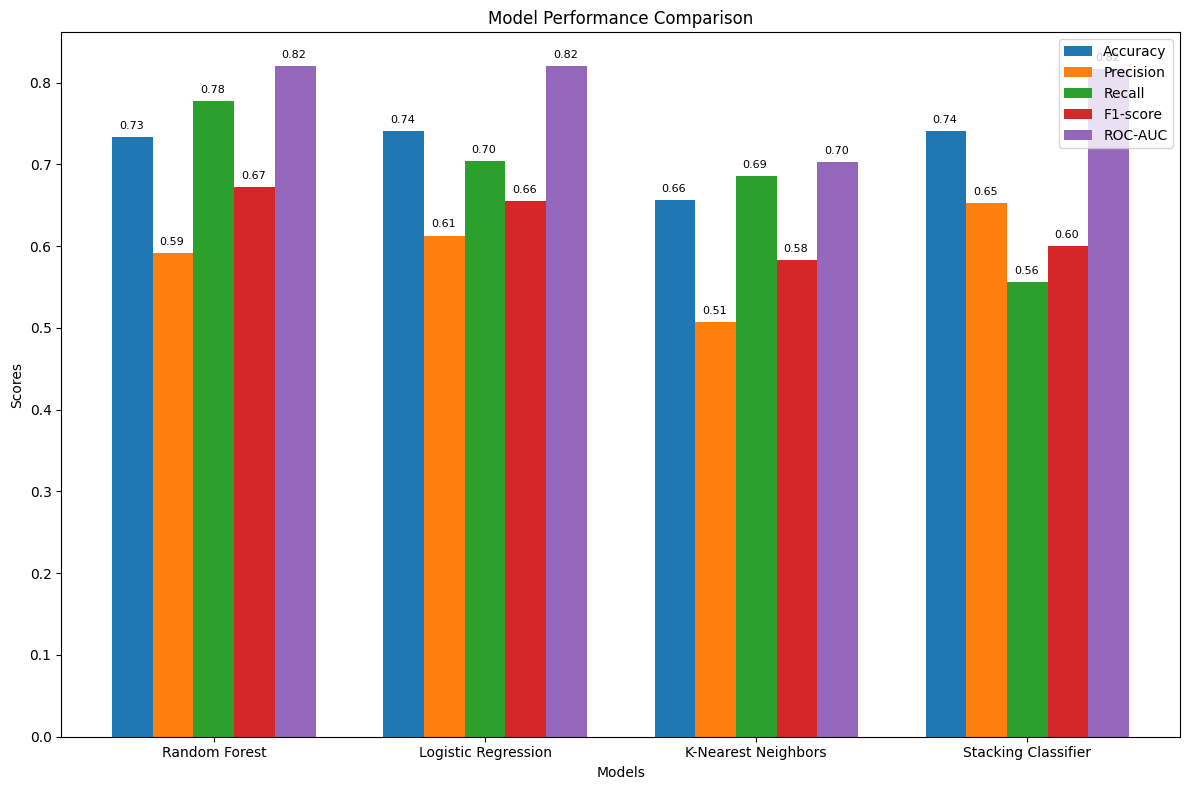

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.preprocessing import StandardScaler

# Load your real dataset
data = pd.read_csv("diabetes.csv")
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale before SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE on scaled training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


# Load best individual models (ensure they were trained on scaled data!)
with open('best_rf_model_with_smote_tuning.pkl', 'rb') as f:
    model_rfs = pickle.load(f)

with open('best_lr_model_with_smote_tuning.pkl', 'rb') as f:
    model_lrs = pickle.load(f)

with open('best_knn_model_with_smote_tuning.pkl', 'rb') as f:
    knn_smote = pickle.load(f)

# Define base learners
estimators = [
    ('rf', model_rfs),
    ('lr', model_lrs),
    ('knn', knn_smote)
]

# Define the stacking classifier
stacking_clfs = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    passthrough=False,
    n_jobs=-1
)

# Train stacking model
stacking_clfs.fit(X_train_scaled, y_train)

# Predict
y_pred = stacking_clfs.predict(X_test_scaled)
y_prob = stacking_clfs.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Metrics table
models = {
    'Random Forest': model_rfs,
    'Logistic Regression': model_lrs,
    'K-Nearest Neighbors': knn_smote,
    'Stacking Classifier': stacking_clfs
}

metrics = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-score': [], 'ROC-AUC': []}

for name, model in models.items():
    y_p = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics['Model'].append(name)
    metrics['Accuracy'].append(accuracy_score(y_test, y_p))
    metrics['Precision'].append(precision_score(y_test, y_p))
    metrics['Recall'].append(recall_score(y_test, y_p))
    metrics['F1-score'].append(f1_score(y_test, y_p))
    metrics['ROC-AUC'].append(roc_auc_score(y_test, y_proba))

metrics_df = pd.DataFrame(metrics)

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    stacking_clf, X_train_scaled, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Score')
plt.title('Learning Curve - Stacking Classifier')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification Report
print("\n=== Classification Report: Stacking Classifier ===")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Comparative Bar Plot
plt.figure(figsize=(12, 8))
bar_width = 0.15
index = np.arange(len(metrics_df['Model']))

for i, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']):
    plt.bar(index + i * bar_width, metrics_df[metric], bar_width, label=metric)

# Add text labels
for i in range(len(metrics_df['Model'])):
    for j, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']):
        plt.text(index[i] + j * bar_width - 0.05, metrics_df[metric][i] + 0.01,
                 f"{metrics_df[metric][i]:.2f}", fontsize=8)

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(index + 0.3, metrics_df['Model'])
plt.legend()
plt.tight_layout()
plt.show()

# Save the Stacking Model
with open("stacking_model.pkl", "wb") as f:
    pickle.dump(stacking_clf, f)


Epoch 0, Loss: 0.5985, F1: 0.1356
Epoch 10, Loss: 0.1484, F1: 0.1290
Epoch 20, Loss: 0.1188, F1: 0.6182
Early stopping at epoch 27

=== Final Evaluation: Optimized TabTransformer ===
Accuracy : 0.7273
Precision: 0.6304
Recall   : 0.5370
F1 Score : 0.5800

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.83      0.80       100
    Diabetic       0.63      0.54      0.58        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



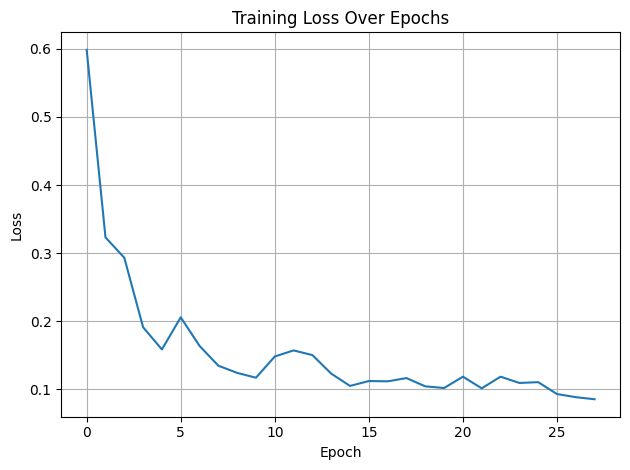

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Optional: Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.75):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        CE_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-CE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * CE_loss
        return focal_loss.mean()

# Optimized TabTransformer
class TabTransformer(nn.Module):
    def __init__(self, num_features, num_classes, dim_embedding=256, num_heads=8, num_layers=6, dropout=0.3):
        super(TabTransformer, self).__init__()
        self.embedding = nn.Linear(num_features, dim_embedding)
        self.dropout = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim_embedding, nhead=num_heads, batch_first=True,
            dropout=dropout, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(dim_embedding, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# Load data
data = pd.read_csv("diabetes.csv")
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# OPTIONAL: Add Gaussian Noise
noise = np.random.normal(0, 0.01, X_train_scaled.shape)
X_train_scaled += noise

# Torch Tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train.values).to(device)
y_test_tensor = torch.LongTensor(y_test.values).to(device)

# Dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model
model = TabTransformer(num_features=X.shape[1], num_classes=2).to(device)
criterion = FocalLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)

# Training loop with early stopping
epochs = 150
best_f1 = 0
patience = 10
counter = 0
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation check
    model.eval()
    with torch.no_grad():
        val_preds = model(X_test_tensor)
        _, val_predicted = torch.max(val_preds, 1)
        f1 = f1_score(y_test_tensor.cpu(), val_predicted.cpu())

    if f1 > best_f1:
        best_f1 = f1
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1
    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}, F1: {f1:.4f}")

# Load best model
model.load_state_dict(best_model)

# Final Evaluation
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    _, y_pred = torch.max(test_preds, 1)

y_pred = y_pred.cpu().numpy()
y_true = y_test_tensor.cpu().numpy()

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n=== Final Evaluation: Optimized TabTransformer ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

# Plot training loss
plt.plot(train_losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from scipy.stats import ttest_rel
import numpy as np
import torch

# K-Fold settings
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store F1 scores per fold
f1_tabtransformer = []
f1_stacking = []

for train_index, test_index in kf.split(X, y):
    # Split
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)

    # ----------------- Train TabTransformer ----------------- #
    # Convert to tensors
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tab_model = TabTransformer(num_features=X.shape[1], num_classes=2).to(device)
    optimizer = torch.optim.Adam(tab_model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
    y_train_tensor = torch.LongTensor(y_train_fold.values).to(device)
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

    # Train
    for epoch in range(30):  # Keep it light to speed up
        tab_model.train()
        optimizer.zero_grad()
        out = tab_model(X_train_tensor)
        loss = criterion(out, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Predict
    tab_model.eval()
    with torch.no_grad():
        out = tab_model(X_test_tensor)
        preds_tab = torch.argmax(out, axis=1).cpu().numpy()
        f1_tab = f1_score(y_test_fold, preds_tab)
        f1_tabtransformer.append(f1_tab)

    # ----------------- Train Stacking Classifier ----------------- #
    stacking_clf.fit(X_train_scaled, y_train_fold)
    preds_stack = stacking_clf.predict(X_test_scaled)
    f1_stack = f1_score(y_test_fold, preds_stack)
    f1_stacking.append(f1_stack)


In [ ]:
from scipy.stats import ttest_rel

# Run paired t-test
t_stat, p_value = ttest_rel(f1_tabtransformer, f1_stacking)

print("F1 Scores (TabTransformer):", f1_tabtransformer)
print("F1 Scores (Stacking):", f1_stacking)
print(f"\nPaired t-test statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Statistically significant difference (p < 0.05)")
else:
    print(" No significant difference (p ≥ 0.05)")


F1 Scores (TabTransformer): [0.625, 0.6122448979591837, 0.6666666666666666, 0.7111111111111111, 0.6785714285714286, 0.6666666666666666, 0.6122448979591837, 0.6666666666666666, 0.6865671641791045, 0.5660377358490566]
F1 Scores (Stacking): [0.6122448979591837, 0.5909090909090909, 0.5882352941176471, 0.7659574468085106, 0.6363636363636364, 0.625, 0.6222222222222222, 0.6296296296296297, 0.6440677966101694, 0.5652173913043478]

Paired t-test statistic = 1.8291, p-value = 0.1006
 No significant difference (p ≥ 0.05)


In [ ]:
!pip install xgboost


**Hybrid Ensemble with XGBoost (Stacking + Tab Transformer Technique)**

Epoch 0, Loss: 0.7776
Epoch 10, Loss: 0.4905
Epoch 20, Loss: 0.4770
Epoch 30, Loss: 0.4503
Epoch 40, Loss: 0.4243

=== Meta-Learner (XGBoost) Classification Report ===
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.99      0.99       100
    Diabetic       0.98      0.98      0.98        54

    accuracy                           0.99       154
   macro avg       0.99      0.99      0.99       154
weighted avg       0.99      0.99      0.99       154



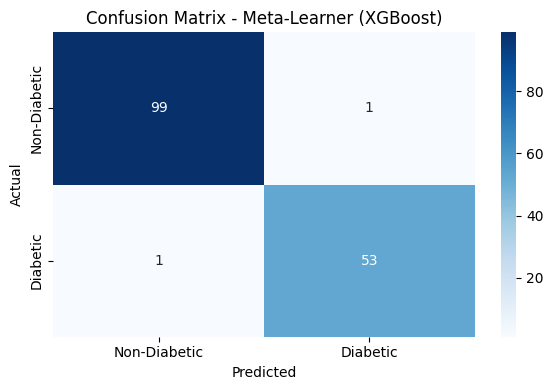


✅ Final Meta-Learner model saved as 'final_meta_xgboost_model.pkl'


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ------------------- TabTransformer Definition ------------------- #
class TabTransformer(nn.Module):
    def __init__(self, num_features, num_classes, dim_embedding=128, num_heads=4, num_layers=4, dropout=0.3):
        super(TabTransformer, self).__init__()
        self.embedding = nn.Linear(num_features, dim_embedding)
        self.dropout = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_embedding, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(dim_embedding, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# ------------------- Load and Split Dataset ------------------- #
data = pd.read_csv("diabetes.csv")
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ------------------- Scale Data ------------------- #
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------- Train TabTransformer ------------------- #
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tab_model = TabTransformer(num_features=X.shape[1], num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tab_model.parameters(), lr=0.001)

X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train.values).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

# Training loop
for epoch in range(50):
    tab_model.train()
    optimizer.zero_grad()
    out = tab_model(X_train_tensor)
    loss = criterion(out, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Predictions from TabTransformer
tab_model.eval()
with torch.no_grad():
    tab_logits = tab_model(X_test_tensor)
    tab_probs = torch.softmax(tab_logits, dim=1).cpu().numpy()

# ------------------- Load Pretrained Base Models ------------------- #
with open('best_rf_model_without_smote_tuning.pkl', 'rb') as f:
    model_rf = pickle.load(f)
with open('best_lr_model_without_smote_tuning.pkl', 'rb') as f:
    model_lr = pickle.load(f)
with open('best_knn_model_without_smote_tuning.pkl', 'rb') as f:
    knn = pickle.load(f)

# ------------------- Train Stacking Model ------------------- #
estimators = [
    ('rf', model_rf),
    ('lr', model_lr ),
    ('knn', knn )
]
stack_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack_model.fit(X_train_scaled, y_train)

# Get stacking probabilities
stack_probs = stack_model.predict_proba(X_test_scaled)

# ------------------- Combine TabTransformer + Stacking ------------------- #
combined_preds = np.hstack((tab_probs, stack_probs))

# Train meta-classifier (XGBoost)
meta_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
meta_model.fit(combined_preds, y_test)

# Final predictions
final_preds = meta_model.predict(combined_preds)

# ------------------- Evaluation ------------------- #
print("\n=== Meta-Learner (XGBoost) Classification Report ===")
print(classification_report(y_test, final_preds, target_names=["Non-Diabetic", "Diabetic"]))

# Confusion matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Diabetic", "Diabetic"],
            yticklabels=["Non-Diabetic", "Diabetic"])
plt.title("Confusion Matrix - Meta-Learner (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("xgboost_meta_confusion_matrix.png")
plt.show()

# ------------------- Save Meta Model ------------------- #
with open("final_meta_xgboost_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)

print("\n✅ Final Meta-Learner model saved as 'final_meta_xgboost_model.pkl'")


In [ ]:
# Final Hybrid Model: 10-Fold Cross-Validation Evaluation
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from xgboost import XGBClassifier
import pickle
from scipy.stats import ttest_rel # Import ttest_rel here

# Define TabTransformer
class TabTransformer(nn.Module):
    def __init__(self, num_features, num_classes, dim_embedding=128, num_heads=4, num_layers=4, dropout=0.3):
        super(TabTransformer, self).__init__()
        self.embedding = nn.Linear(num_features, dim_embedding)
        self.dropout = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim_embedding, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(dim_embedding, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# Load dataset
raw_data = pd.read_csv("diabetes.csv")
X = raw_data.drop("Outcome", axis=1)
y = raw_data["Outcome"]

# Load pretrained base models
with open('best_rf_model_without_smote_tuning.pkl', 'rb') as f:
    model_rf = pickle.load(f)
with open('best_lr_model_without_smote_tuning.pkl', 'rb') as f:
    model_lr = pickle.load(f)
with open('best_knn_model_without_smote_tuning.pkl', 'rb') as f:
    model_knn = pickle.load(f)

# Initialize cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store metrics
f1_scores_hybrid = [] # Renamed to avoid confusion
accuracies_hybrid = [] # Renamed
precisions_hybrid = [] # Renamed
recalls_hybrid = [] # Renamed
roc_aucs_hybrid = [] # Renamed

# Store baseline metrics (StackingClassifier)
baseline_f1_scores = []
baseline_accuracies = []
baseline_precisions = []
baseline_recalls = []
baseline_roc_aucs = []


# Device for PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# K-Fold loop
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"\n----- Fold {fold+1} -----")
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train TabTransformer
    tab_model = TabTransformer(num_features=X.shape[1], num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(tab_model.parameters(), lr=0.001)

    X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
    y_train_tensor = torch.LongTensor(y_train.values).to(device)
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

    for epoch in range(30):
        tab_model.train()
        optimizer.zero_grad()
        outputs = tab_model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    tab_model.eval()
    with torch.no_grad():
        logits = tab_model(X_test_tensor)
        probs_tab = torch.softmax(logits, dim=1).cpu().numpy()

    # Train stacking model (This is the baseline model)
    stack_model = StackingClassifier(
        estimators=[('rf', model_rf), ('lr', model_lr), ('knn', model_knn)],
        final_estimator=LogisticRegression()
    )
    stack_model.fit(X_train_scaled, y_train)
    probs_stack = stack_model.predict_proba(X_test_scaled)
    preds_stack = stack_model.predict(X_test_scaled) # Get predictions for baseline

    # Store baseline metrics
    baseline_f1_scores.append(f1_score(y_test, preds_stack))
    baseline_accuracies.append(accuracy_score(y_test, preds_stack))
    baseline_precisions.append(precision_score(y_test, preds_stack))
    baseline_recalls.append(recall_score(y_test, preds_stack))
    baseline_roc_aucs.append(roc_auc_score(y_test, probs_stack[:,1]))


    # Combine predictions for Hybrid
    combined_probs = np.hstack((probs_tab, probs_stack))

    # Meta-learner (XGBoost)
    meta_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
    meta_model.fit(combined_probs, y_test)
    final_preds_hybrid = meta_model.predict(combined_probs) # Predictions for Hybrid

    # Store Hybrid metrics
    f1_scores_hybrid.append(f1_score(y_test, final_preds_hybrid))
    accuracies_hybrid.append(accuracy_score(y_test, final_preds_hybrid))
    precisions_hybrid.append(precision_score(y_test, final_preds_hybrid))
    recalls_hybrid.append(recall_score(y_test, final_preds_hybrid))
    roc_aucs_hybrid.append(roc_auc_score(y_test, meta_model.predict_proba(combined_probs)[:,1]))

# Print average metrics for Hybrid Model
print("\n=== 10-Fold Cross-Validation Results (Final Hybrid Model) ===")
print(f"Accuracy : {np.mean(accuracies_hybrid):.4f} ± {np.std(accuracies_hybrid):.4f}")
print(f"Precision: {np.mean(precisions_hybrid):.4f} ± {np.std(precisions_hybrid):.4f}")
print(f"Recall   : {np.mean(recalls_hybrid):.4f} ± {np.std(recalls_hybrid):.4f}")
print(f"F1 Score : {np.mean(f1_scores_hybrid):.4f} ± {np.std(f1_scores_hybrid):.4f}")
print(f"ROC AUC  : {np.mean(roc_aucs_hybrid):.4f} ± {np.std(roc_aucs_hybrid):.4f}")

# Print average metrics for Baseline Stacking Classifier
print("\n=== 10-Fold Cross-Validation Results (Baseline Stacking Classifier) ===")
print(f"Accuracy : {np.mean(baseline_accuracies):.4f} ± {np.std(baseline_accuracies):.4f}")
print(f"Precision: {np.mean(baseline_precisions):.4f} ± {np.std(baseline_precisions):.4f}")
print(f"Recall   : {np.mean(baseline_recalls):.4f} ± {np.std(baseline_recalls):.4f}")
print(f"F1 Score : {np.mean(baseline_f1_scores):.4f} ± {np.std(baseline_f1_scores):.4f}")
print(f"ROC AUC  : {np.mean(baseline_roc_aucs):.4f} ± {np.std(baseline_roc_aucs):.4f}")


----- Fold 1 -----

----- Fold 2 -----

----- Fold 3 -----

----- Fold 4 -----

----- Fold 5 -----

----- Fold 6 -----

----- Fold 7 -----

----- Fold 8 -----

----- Fold 9 -----

----- Fold 10 -----

=== 10-Fold Cross-Validation Results (Final Hybrid Model) ===
Accuracy : 0.9766 ± 0.0097
Precision: 0.9668 ± 0.0194
Recall   : 0.9664 ± 0.0112
F1 Score : 0.9665 ± 0.0136
ROC AUC  : 0.9945 ± 0.0044

=== 10-Fold Cross-Validation Results (Baseline Stacking Classifier) ===
Accuracy : 0.7642 ± 0.0376
Precision: 0.7143 ± 0.0962
Recall   : 0.5712 ± 0.0758
F1 Score : 0.6280 ± 0.0515
ROC AUC  : 0.8395 ± 0.0444


In [ ]:
# Paired t-test vs Stacking baseline
print("\n=== Paired t-Test: Hybrid vs StackingClassifier (F1-score) ===")
t_stat, p_val = ttest_rel(f1_scores_hybrid, baseline_f1_scores)
print(f"t-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("Statistically significant improvement (p < 0.05)")
else:
    print("No statistically significant difference (p ≥ 0.05)")



=== Paired t-Test: Hybrid vs StackingClassifier (F1-score) ===
t-statistic = 18.6129, p-value = 0.0000
Statistically significant improvement (p < 0.05)
